In [1]:
import os
import sys
from os.path import join
import copy

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)
    
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader
from sklearn.linear_model import Ridge
from sklearn.feature_selection import mutual_info_regression
import pyxis.torch as pxt
import dcor

from networks import *
from train import *
import config
from model_registry import load_model_config

model_name = 'ViT-CNN'
data_dir = '/ocean/projects/phy250048p/shared/datasets/valid_1m'
fig_dir = '/ocean/projects/phy250048p/shared/figures/'
model_dir = '/ocean/projects/phy250048p/shared/models/'

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
model_cfg = load_model_config(model_name, allow_fallback_current=True)
config.set_model_config(model_cfg)

In [4]:
model = load_model(
    # mode=1,
    train_config=config.pretrain,
    Model=VICRegPretrain,
    path=join(model_dir, model_name, f'{model_name}41'),
    strict=True,
    assign=True,
    device=device,
    model_name=model_name,
    networks_root='/ocean/projects/phy250048p/shared/networks',
    use_compile=False,
)

In [5]:
# Get data loader
bs = 100
test_args = list(config.test.values())
test_ds = pxt.TorchDataset(data_dir)
test_dl = DataLoader(test_ds,
                     batch_size=bs,
                     pin_memory=False,
                     shuffle=False,)

In [6]:
# snrs = torch.rand((len(test_ds),), device=device)*995 + 5
snrs = torch.full((len(test_ds),), 1000.0, device=device)  # For testing, use a fixed SNR of 1000
features = []
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_dl):
        start = i*bs
        end = min((i+1)*bs, len(test_ds))
        snr = snrs[start:end]
        img = apply_noise(batch['img'].float().to(device), snr, device=device)
        spec = apply_noise(batch['spec'].float().to(device), snr, device=device)
        fp = batch['fib_pos'].float().to(device)
        features.append(model.extract_features(img, spec, fp).cpu())

In [7]:
features = torch.cat(features, dim=0).detach().cpu().numpy()

In [8]:
fids = [batch['fid_pars'] for batch in test_dl]
fids = torch.cat(fids, dim=0).detach().cpu().numpy()

In [9]:
g1 = fids[:, 0]
g2 = fids[:, 1]

g_centers = np.linspace(-0.095, 0.095, 20)
g_edges = np.linspace(-0.1, 0.1, 21)
g1_bins = np.digitize(g1, g_edges) - 1
g2_bins = np.digitize(g2, g_edges) - 1

In [10]:
sini = fids[:, 3]

sini_bins = np.digitize(sini, g_edges) - 1

In [11]:
# x_train = features[:90000]
# g_train = fids[:90000, 0:2]
# x_val = features[90000:]
# g_val = fids[90000:, 0:2]
x_train = features
g_train = fids
x_val = features
g_val = fids

In [12]:
# 1. Fit a simple probe from backbone features (x) to shear (g)
# x: shape (N, D), g: shape (N, 2)
probe = Ridge(alpha=1.0).fit(x_train, g_train)
g_hat = probe.predict(x_val)

# 2. Compute 1D mutual information for g1 and g2 using KSG k-NN
mi_g1_bins = []
for i in range(20):
    mask = (g1_bins == i)
    mi_g1_bins.append(mutual_info_regression(g_hat[:, [0]][mask], g_val[mask, 0], n_neighbors=10)[0])

mi_g2_bins = []
for i in range(20):
    mask = (g2_bins == i)
    mi_g2_bins.append(mutual_info_regression(g_hat[:, [1]][mask], g_val[mask, 1], n_neighbors=10)[0])

mi_sini_bins = []
for i in range(20):
    mask = (sini_bins == i)
    mi_sini_bins.append(mutual_info_regression(g_hat[:, [3]][mask], g_val[mask, 3], n_neighbors=10)[0])

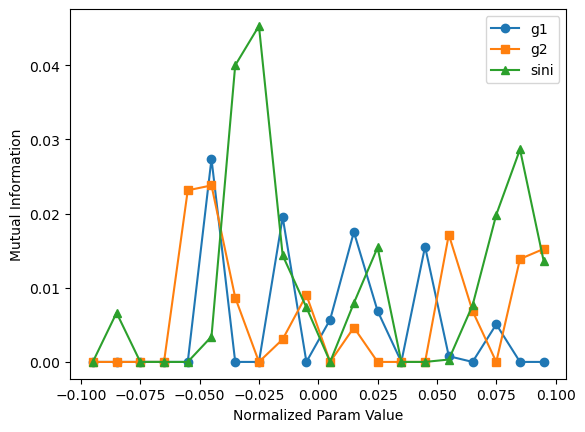

In [13]:
plt.plot(g_centers, mi_g1_bins, label='g1', marker='o')
plt.plot(g_centers, mi_g2_bins, label='g2', marker='s')
plt.plot(g_centers, mi_sini_bins, label='sini', marker='^')

plt.xlabel('Normalized Param Value')
plt.ylabel('Mutual Information')
plt.legend()
plt.show()

In [14]:
class FeatureProbe(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 8) # Predicts g1, g2
        )
    def forward(self, x):
        return self.net(x)

In [15]:
nonlin_probe = FeatureProbe(in_dim=features.shape[1], hidden_dim=128).to(device)
loss_func = nn.MSELoss()
optimizer = torch.optim.AdamW(nonlin_probe.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
nonlin_probe.train()
for epoch in range(20):
    epoch_loss = 0.0
    for i, batch in enumerate(test_dl):
        start = i*bs
        end = min((i+1)*bs, len(test_ds))
        x_batch = features[start:end]
        g_batch = fids[start:end]
        x_tensor = torch.from_numpy(x_batch).float().to(device)
        g_tensor = torch.from_numpy(g_batch).float().to(device)
        optimizer.zero_grad()
        g_pred = nonlin_probe(x_tensor)
        loss = loss_func(g_pred, g_tensor)
        loss.backward()
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}, Batch {i+1}, Loss: {epoch_loss / (i + 1):.4f}")

Epoch 1, Batch 1000, Loss: 0.1697
Epoch 2, Batch 1000, Loss: 0.1361
Epoch 3, Batch 1000, Loss: 0.1284
Epoch 4, Batch 1000, Loss: 0.1237
Epoch 5, Batch 1000, Loss: 0.1201
Epoch 6, Batch 1000, Loss: 0.1172
Epoch 7, Batch 1000, Loss: 0.1149
Epoch 8, Batch 1000, Loss: 0.1132
Epoch 9, Batch 1000, Loss: 0.1118
Epoch 10, Batch 1000, Loss: 0.1107
Epoch 11, Batch 1000, Loss: 0.1097
Epoch 12, Batch 1000, Loss: 0.1089
Epoch 13, Batch 1000, Loss: 0.1082
Epoch 14, Batch 1000, Loss: 0.1075
Epoch 15, Batch 1000, Loss: 0.1069
Epoch 16, Batch 1000, Loss: 0.1063
Epoch 17, Batch 1000, Loss: 0.1058
Epoch 18, Batch 1000, Loss: 0.1054
Epoch 19, Batch 1000, Loss: 0.1049
Epoch 20, Batch 1000, Loss: 0.1045


In [20]:
nonlin_probe.eval()
g_pred = nonlin_probe(torch.from_numpy(features).float().to(device)).detach().cpu().numpy()

In [ ]:
r2_g1_bins = []
r2_g2_bins = []
r2_sini_bins = []
for i in range(20):
    mask_g1 = (g1_bins == i)
    r2_g1_bins.append(r2_score(g_val[:500, 0], g_pred[:500, 0]))
    mask_g2 = (g2_bins == i)
    r2_g2_bins.append(r2_score(g_val[mask_g2, 1], g_pred[mask_g2, 1]))
    mask_sini = (sini_bins == i)
    r2_sini_bins.append(r2_score(g_val[mask_sini, 3], g_pred[mask_sini, 3]))

r2_g1 = r2_score(g_val[:, 0], g_pred[:, 0])
r2_g2 = r2_score(g_val[:, 1], g_pred[:, 1])
r2_sini = r2_score(g_val[:, 3], g_pred[:, 3])
print(f"Overall R^2 Scores: g1: {r2_g1:.4f}, g2: {r2_g2:.4f}, sini: {r2_sini:.4f}")

500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
Overall R^2 Scores: g1: 0.5215, g2: 0.5129, sini: 0.8360


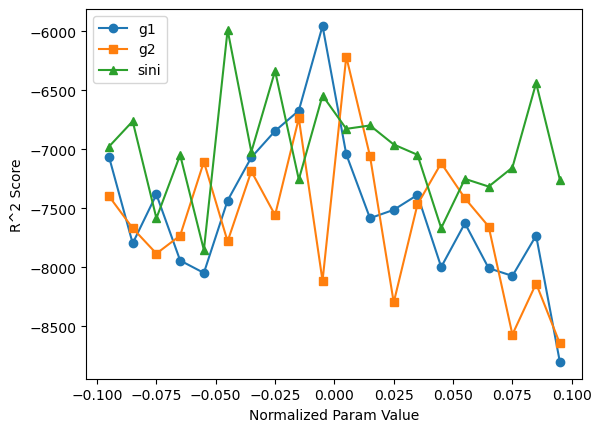

In [30]:
plt.plot(g_centers, r2_g1_bins, label='g1', marker='o')
plt.plot(g_centers, r2_g2_bins, label='g2', marker='s')
plt.plot(g_centers, r2_sini_bins, label='sini', marker='^')

plt.xlabel('Normalized Param Value')
plt.ylabel('R^2 Score')
plt.legend()
plt.show()

In [9]:
vicreg_loss = VICRegLoss()

In [10]:
total_loss, sim_component, var_component, cov_component, eff_dim_z1, eff_dim_z2 = vicreg_loss(z1, z2, return_components=True)

In [11]:
print(total_loss, sim_component, var_component, cov_component, eff_dim_z1, eff_dim_z2)

tensor(5654.8799) tensor(59.1464) tensor(18.9802) tensor(5576.7534) tensor(2.7833) tensor(1.0545)
